Computing a global dendrogram by merging local dendrograms
==========================================================

Let's start by doing some imports and defining the data

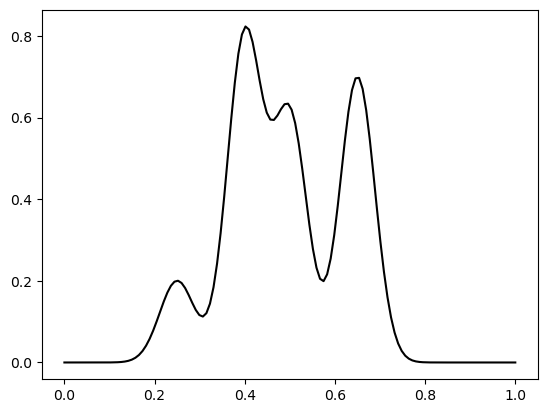

In [1]:
import heat as ht
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram

x, data = get_1d_data(128)
plt.plot(x.larray, data.larray, color='black')

Next, we are going to split up the data into chunks that we will compute the dendrograms independently on.
We include a halo, so that we can later tell if we need to merge structures from adjacent dendrograms

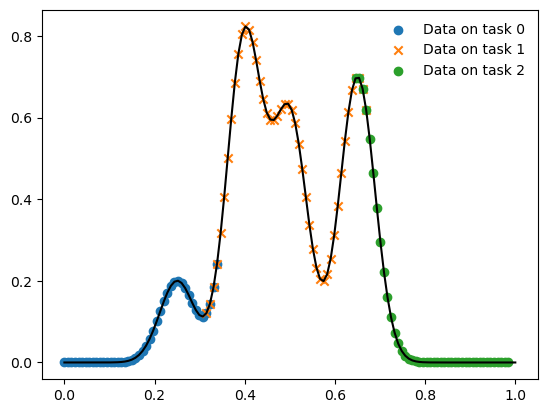

In [2]:
ntasks = 3
elements_per_task = data.shape[0] // ntasks
halo_size = 2
local_slices = [slice(i*elements_per_task, (i+1)*elements_per_task) for i in range(ntasks)]
for i in range(ntasks):
    start = i * elements_per_task
    stop = start + elements_per_task
    if i > 0:
        start -= halo_size
    if i < ntasks - 1:
        stop += halo_size
    local_slices[i] = slice(start, stop)


plt.plot(x.larray, data.larray, color='black')
for i in range(ntasks):
    s = local_slices[i]
    marker = 'o' if i % 2 == 0 else 'x'
    plt.scatter(x[s], data[s], marker=marker, label=f'Data on task {i}')
plt.legend(frameon=False)

Next, we simply compute dendrograms on the local data.
After we have computed them, we add the shift from local data to global data.

In [3]:

local_dendrograms = [Dendrogram.compute(np.array(data[s].larray)) for s in local_slices]

def add_offset_to_astrodendro_data(offset, leaves):
    for leaf in leaves:
        leaf._indices = np.array([index[0] + offset for index in leaf._indices])
        add_offset_to_astrodendro_data(offset, leaf._children)
for i in range(ntasks):
    add_offset_to_astrodendro_data(offset=local_slices[i].start, leaves=local_dendrograms[i].trunk)

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_55669/1392865260.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  local_dendrograms = [Dendrogram.compute(np.array(data[s].larray)) for s in local_slices]


Let's plot the local dendrograms

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_55669/2679701696.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])


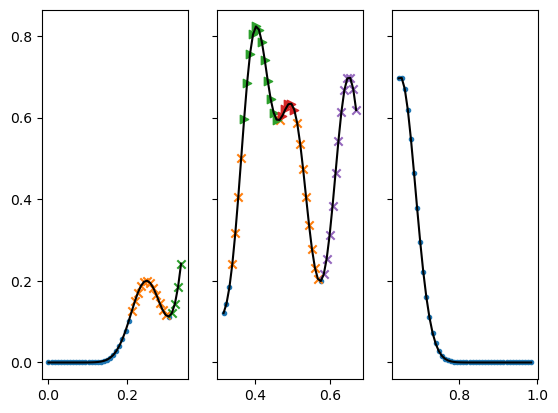

In [4]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", "4": "<"}
    for leaf in leaves:
        ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)

fig, axs = plt.subplots(1, ntasks, sharey=True)
for i in range(ntasks):
    ax = axs[i] if ntasks > 1 else axs
    ax.plot(x[local_slices[i]].larray, data[local_slices[i]].larray, color='black')

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Now, we need to merge the local dendrograms to global ones.
When doing this, we need to watch out get the tree structure right.

We need to ...
- ... merge the edges of adjacent dendrograms to the structure the neighboring halo belongs to
- ... merge structures near the trunk that belong to together
- ... split structures near the trunk if there is a smaller local minimum somewhere else

Let's start by identifying the global trunk

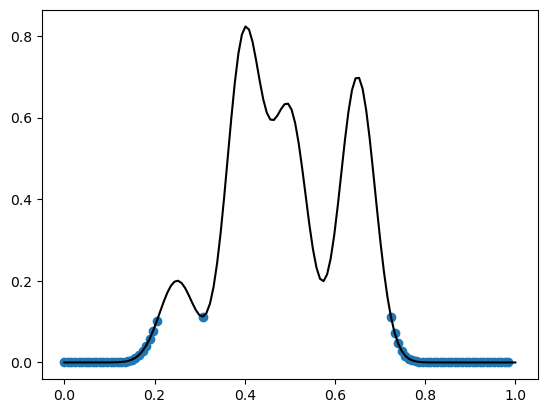

In [5]:
from astrodendro.dendrogram import Structure

def get_global_trunk(leaves):
    next_leaf_idx = []
    leaf_max = min([ht.max(data[leaf._indices]) for leaf in leaves])
    for i in range(ntasks):
        for leaf in leaves:
            leaf_indices = leaf._indices
            mask = data[leaf_indices] <= leaf_max
            next_leaf_idx += list(leaf_indices[mask])
            leaf._indices = np.array(leaf_indices[~mask])

    trunk = Structure(indices=next_leaf_idx, values=data[next_leaf_idx])
    return trunk

leaves = [leaf for d in local_dendrograms for leaf in d.trunk]
trunk = get_global_trunk(leaves)

fig, ax = plt.subplots()
ax.plot(x.larray, data.larray, color='black')
ax.scatter(x[trunk._indices], data[trunk._indices], label='global trunk')

Let's see what is left of the local dendrograms that needs to be assigned to the global tree

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_55669/2679701696.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.scatter(np.array(x)[leaf._indices], np.array(data)[leaf._indices], marker=markers[level])


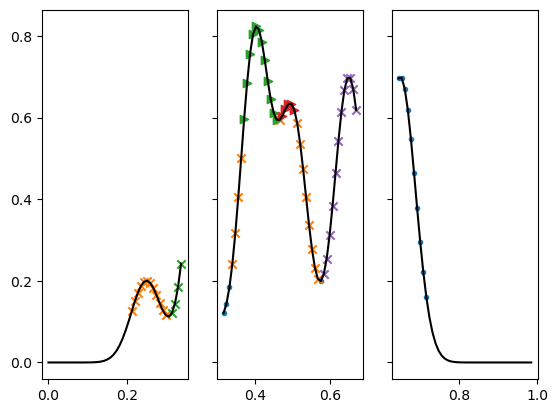

In [6]:
fig, axs = plt.subplots(1, ntasks, sharey=True)
for i in range(ntasks):
    ax = axs[i] if ntasks > 1 else axs
    ax.plot(x[local_slices[i]].larray, data[local_slices[i]].larray, color='black')

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Ok, now we go through all the remaining data and add structures as child structures to our trunk

First, we update the list of leaves to merge from:

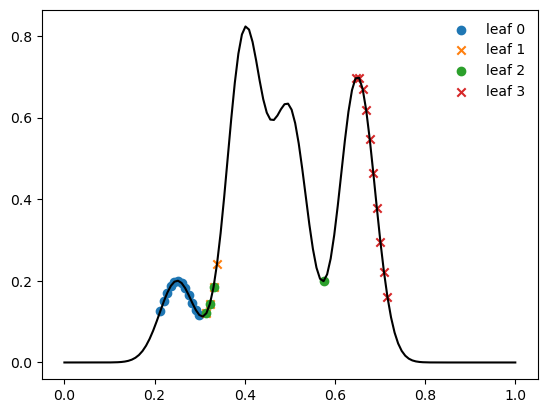

In [7]:
def update_leaves(leaves):
    return [me for leaf in leaves for me in ([leaf] if len(leaf._indices) > 0 else leaf.children)]

leaves = update_leaves(leaves)

fig, ax = plt.subplots()
ax.plot(x.larray, data.larray, color='black')
for i in range(len(leaves)):
    marker = 'o' if i % 2 == 0 else 'x'
    leaf = leaves[i]
    ax.scatter(x[leaf._indices].larray, data[leaf._indices].larray, marker=marker, label=f'leaf {i}')
ax.legend(frameon=False)

Earlier, we used a halo to identify which structures belong to neighboring structures.
Let's next merge the neighboring structures

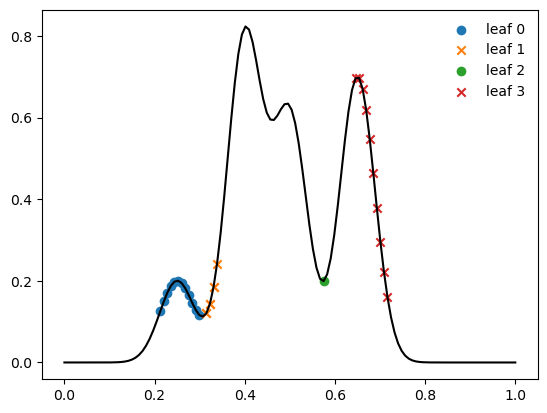

In [8]:
def merge_leaves(leaves):
    new_leaves = []
    for i in range(len(leaves) - 1):
        intersection = [idx for idx in leaves[i]._indices if idx in leaves[i+1]._indices]
        if len(intersection) == 0:
            new_leaves.append(leaves[i])
        else:
            leaves[i]._indices = np.append(leaves[i]._indices, intersection)
            new_leaves.append(leaves[i])
            leaves[i+1]._indices = np.array([idx for idx in leaves[i+1]._indices if idx not in intersection])
            if len(leaves[i+1]._indices == 0):
                for child in leaves[i+1]._children:
                    new_leaves.append(child)
    return new_leaves

leafes = merge_leaves(leaves)

fig, ax = plt.subplots()
ax.plot(x.larray, data.larray, color='black')
for i in range(len(leaves)):
    marker = 'o' if i % 2 == 0 else 'x'
    leaf = leaves[i]
    ax.scatter(x[leaf._indices].larray, data[leaf._indices].larray, marker=marker, label=f'leaf {i}')
ax.legend(frameon=False)

Now, we need to decide how to bifurcate these into two structures..

To be continued?

In [9]:


if __name__ == '__main__':
    plt.show()